In [13]:
import sys
from pathlib import Path
# fixing imports for src/ modules
sys.path.append(str(Path().resolve().parents[1]))

import copy
import pprint
import wandb

import torch
import torch.nn as nn
import src.cnn.cnn_paths as paths
import src.cnn.cnn_models as cnn_models
from src.cnn.configs import ExperimentConfig
from src.cnn.cnn_registry import build_model
from src.cnn.cnn_utils import *

In [2]:
# see configs.py
cfg = ExperimentConfig()

# =========================================================
# DATASET CONFIG
# =========================================================
cfg.dataset.dataset_dir = paths.DATASET_DIR # see cnn_paths.py
cfg.dataset.train_subdir = "train"
cfg.dataset.val_subdir = "validate"
cfg.dataset.test_subdir = None   # or "test" if you have it
cfg.dataset.image_size = 224

# leave transforms as None -> default Resize + ToTensor pipeline
cfg.dataset.train_transform = None
cfg.dataset.eval_transform = None

# optional normalization
cfg.dataset.normalize_mean = None
cfg.dataset.normalize_std = None


# =========================================================
# MODEL CONFIG
# IMPORTANT: name is saved in MODEL_REGISTRY -> cnn_registry.py
# use @register_model("depth_cnn") decorator to add new models to the registry and make them available by name in the config
# =========================================================
cfg.model.name = "depth_cnn_fc" # use model from fc testing with only one fully connected layer in the header
cfg.model.kwargs = {
    "depth": 12,
    "in_channels": 3,
    "num_classes": 10,
    "base_channels": 32,
    "max_channels": 256,
    "dropout_conv": 0.0,
    "dropout_fc": 0.5,
    "inputsize": 224,
    "fc_layers": 1,
    # construction decreasing header to keep numbers of parameters in a reasonable range
    "hidden1": 128,
    "hidden2": 64,
    "hidden3": 32,
    "hidden4": 16,
}


# =========================================================
# DATALOADER CONFIG
# =========================================================
cfg.loader.batch_size = 32 # reduced batchsize from learnings in previous experiments
cfg.loader.num_workers = 0
cfg.loader.pin_memory = True
cfg.loader.train_shuffle = True
cfg.loader.eval_shuffle = False
cfg.loader.drop_last_train = False
cfg.loader.drop_last_eval = False


# =========================================================
# LOSS CONFIG
# =========================================================
cfg.loss.cls = nn.CrossEntropyLoss
cfg.loss.kwargs = {}


# =========================================================
# OPTIMIZER CONFIG
# =========================================================
cfg.optimizer.cls = torch.optim.SGD
cfg.optimizer.kwargs = {
    "lr": 0.01, # from previous testings
    "momentum": 0.9, # default value for momentum
    "weight_decay": 1e-4, # deafault value
}


# =========================================================
# SCHEDULER CONFIG
# Example: Reduce LR when validation loss plateaus
# =========================================================
cfg.scheduler.cls = None
cfg.scheduler.kwargs = {
    # "mode": "min",
    # "factor": 0.5,
    # "patience": 2,
}
cfg.scheduler.step_metric = None

# =========================================================
# EARLY STOPPING CONFIG
# OPTIONAL
# For noisy validation curves use:
# early_stopping_patience = 7
# early_stopping_min_delta = 0.001
# =========================================================

cfg.train.early_stopping = True # use early stopping based on validation accuracy to prevent overfitting and save training time
cfg.train.early_stopping_patience = 5
cfg.train.early_stopping_min_delta = 0.0


# =========================================================
# TRAIN CONFIG
# =========================================================
cfg.train.epochs = 100
cfg.train.device = str(get_device("auto"))
cfg.train.non_blocking = True
cfg.train.use_amp = (cfg.train.device == "cuda") # suggestion from ChatGPT for large batch sizes to save memory and speed up training
cfg.train.grad_clip_norm = None
cfg.train.best_metric = "val/accuracy"
cfg.train.best_mode = "max"
cfg.train.seed = 42


# =========================================================
# W&B CONFIG
# =========================================================
cfg.wandb.enabled = True
cfg.wandb.project = "MPW-CNN"
cfg.wandb.entity = "MSE_DeLearn_SPR26"
cfg.wandb.mode = "online"   # "online", "offline", or "disabled" for no logging

# NOTE: use meaningful names for runs, so the difference is clear
cfg.wandb.run_name = f"Final_ModelBatchSize32_depth{cfg.model.kwargs['depth']}_momentum{cfg.optimizer.kwargs['momentum']}_lr{cfg.optimizer.kwargs['lr']}_fc_layers{cfg.model.kwargs['fc_layers']}_e{cfg.train.epochs}"

# NOTE: use meaningful grouping, for example, by model or by task.
# E.g. task "Data augmentation" => experiments on light-mid-heavy augmentation
cfg.wandb.group = "Final_Model"
cfg.wandb.job_type = "train"

# NOTE: use meaningful tags to filter runs in UI
cfg.wandb.tags = ["deep_cnn", "Final_model"]
cfg.wandb.notes = "Full config live run"

cfg.wandb.log_epoch_metrics = True
cfg.wandb.log_every_n_epochs = 1

cfg.wandb.metric_allowlist = {
    "train/loss",
    "train/accuracy",
    "val/loss",
    "val/accuracy",
    "gap/accuracy",
    "gap/loss",
    "lr",
}

cfg.wandb.summary_allowlist = {
    "best_epoch",
    "best_metric_name",
    "best_metric_value",
    "train_final/loss",
    "train_final/accuracy",
    "val_final/loss",
    "val_final/accuracy",
}

cfg.wandb.watch_model = False
cfg.wandb.watch_log = "all"
cfg.wandb.watch_log_freq = 100

In [3]:
# Model builder from config

model = build_model(cfg.model)

print(model)
print(f"Trainable parameters: {get_num_parameters(model):,}")

DepthCNNFC(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=same, bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=same, bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same, bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (3): ConvBlock(
      (block): Sequential(
   

In [5]:
model, history, result = run_experiment(cfg)
pprint.pprint(result)

Train dataset:
  num_samples: 24000
  num_classes: 10
  class distribution:
    cat: 2400
    chicken: 2400
    cow: 2400
    dog: 2400
    elephant: 2400
    horse: 2400
    rabbit: 2400
    sheep: 2400
    squirrel: 2400
    zebra: 2400

Validation dataset:
  num_samples: 6000
  num_classes: 10
  class distribution:
    cat: 600
    chicken: 600
    cow: 600
    dog: 600
    elephant: 600
    horse: 600
    rabbit: 600
    sheep: 600
    squirrel: 600
    zebra: 600


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\lucas\_netrc.



DepthCNNFC(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=same, bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=same, bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same, bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (3): ConvBlock(
      (block): Sequential(
  

wandb: Currently logged in as: lucas-j-keller98 (MSE_DeLearn_SPR26) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch [001/100] | train_loss=1.7475 | train_acc=0.3680 | val_loss=1.4813 | val_acc=0.4668 | time=36.8s
Epoch [002/100] | train_loss=1.3650 | train_acc=0.5250 | val_loss=1.8793 | val_acc=0.4392 | time=34.1s
Epoch [003/100] | train_loss=1.1512 | train_acc=0.6014 | val_loss=1.2143 | val_acc=0.5730 | time=34.2s
Epoch [004/100] | train_loss=0.9933 | train_acc=0.6561 | val_loss=0.9817 | val_acc=0.6500 | time=34.1s
Epoch [005/100] | train_loss=0.8479 | train_acc=0.7097 | val_loss=0.9011 | val_acc=0.6932 | time=34.0s
Epoch [006/100] | train_loss=0.7354 | train_acc=0.7527 | val_loss=0.8165 | val_acc=0.7253 | time=34.1s
Epoch [007/100] | train_loss=0.6330 | train_acc=0.7915 | val_loss=0.6843 | val_acc=0.7673 | time=34.2s
Epoch [008/100] | train_loss=0.5490 | train_acc=0.8174 | val_loss=0.6077 | val_acc=0.7955 | time=34.1s
Epoch [009/100] | train_loss=0.4859 | train_acc=0.8352 | val_loss=0.8024 | val_acc=0.7525 | time=34.2s
Epoch [010/100] | train_loss=0.4306 | train_acc=0.8554 | val_loss=0.5755 

epoch,▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇██
gap/accuracy,▄▂▁▁▂▂▄▅▃▄▇▅▅▆▅▇▅▆▆█▆▆▅▆▆▅▅▅▅▅█▅▆▅▅▅▅▅▅▅
gap/loss,▁▃▃▃▃▄▄▅▄▅▆▅▆▅▆▆▆▆█▆▆▆▆▆▆▆▆▆▆█▆▆▅▆▆▅▆▆▅▅
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/accuracy,▁▃▄▄▅▆▆▆▇▇▇▇▇▇██████████████████████████
train/loss,█▆▅▄▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/accuracy,▁▁▃▅▅▆▇▆▇▇▆▇▇▇▇▇█▇▇▇█▇▇██▇███████▇██████
val/loss,▆█▅▃▂▃▂▁▂▂▂▁▂▁▂▁▁▂▃▂▂▁▂▂▂▂▁▁▂▁▃▂▁▁▁▁▁▁▁▁
best_epoch,50
best_metric_name,val/accuracy
best_metric_value,0.898


{'Stopped_early': True,
 'best_epoch': 50,
 'best_metric_name': 'val/accuracy',
 'best_metric_value': 0.898,
 'epochs_completed': 55,
 'timestamp': '20260409_220638',
 'train_final/accuracy': 1.0,
 'train_final/loss': 0.0002497345085866982,
 'val_final/accuracy': 0.898,
 'val_final/loss': 0.41353718703721337,
 'wandb_run_id': '062qmp15'}


In [9]:
ckpt_path = paths.CKPT_DIR  # in data/checkpoints/

# Checkpoint file with timestamp of when the training was completed (in train_eval)
checkpoint_file = str(cfg.wandb.run_name) + '_' + result["timestamp"] + ".pth"

save_checkpoint(
    path=ckpt_path,
    filename=checkpoint_file,
    model=model,
    cfg=cfg,
    extra={"result": result},
)

In [14]:
import wandb

if cfg.wandb.enabled and cfg.wandb.mode != "disabled":
    with wandb.init(
        project=cfg.wandb.project,
        entity=cfg.wandb.entity,
        job_type="log_checkpoint",
        #name=f"{cfg.wandb.run_name}_artifact",
        mode=cfg.wandb.mode,
        id=result["wandb_run_id"], # add to the same run!
        resume="must",              # for that, run is resumed
    ):
        log_checkpoint_artifact(
            path=ckpt_path,
            filename=checkpoint_file,
            cfg=cfg,
            result=result,
        )

best_epoch,50
best_metric_name,val/accuracy
best_metric_value,0.898
epoch,55
gap/accuracy,0.10229
gap/loss,0.41355
lr,0.01
train/accuracy,0.99979
train/loss,0.00205
train_final/accuracy,1
+5,...


In [17]:
# see cnn_utils.py
datasets_dict = load_datasets(cfg.dataset)

train_dataset = datasets_dict["train"]
val_dataset = datasets_dict["val"]
test_dataset = datasets_dict.get("test")

In [18]:
train_loader = make_train_loader(train_dataset, cfg)
val_loader = make_eval_loader(val_dataset, cfg)

test_loader = None
if test_dataset is not None:
    test_loader = make_eval_loader(test_dataset, cfg)

In [19]:
cfg_eval = copy.deepcopy(cfg)
cfg_eval.train.device = "cpu"

model_cpu = model.to("cpu").eval()

if torch.backends.mps.is_available():
    torch.mps.synchronize()
    torch.mps.empty_cache()

loader_for_cm = test_loader if test_loader is not None else val_loader
split_name = "test" if test_loader is not None else "val"
class_names = loader_for_cm.dataset.classes

y_true, y_pred = predict_loader(model_cpu, loader_for_cm, cfg_eval)

print("structure of predictions/true labels:")
print("true label counts:", Counter(y_true))
print("pred label counts:", Counter(y_pred))
print("class_names:", class_names)

print("Unique y_true:", sorted(set(y_true)))
print("Unique y_pred:", sorted(set(y_pred)))

structure of predictions/true labels:
true label counts: Counter({0: 600, 1: 600, 2: 600, 3: 600, 4: 600, 5: 600, 6: 600, 7: 600, 8: 600, 9: 600})
pred label counts: Counter({8: 633, 4: 624, 5: 613, 3: 603, 1: 599, 7: 594, 9: 593, 2: 585, 6: 579, 0: 577})
class_names: ['cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'rabbit', 'sheep', 'squirrel', 'zebra']
Unique y_true: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Unique y_pred: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


best_epoch,50
best_metric_name,val/accuracy
best_metric_value,0.898
epoch,55
gap/accuracy,0.10229
gap/loss,0.41355
lr,0.01
train/accuracy,0.99979
train/loss,0.00205
train_final/accuracy,1
+5,...


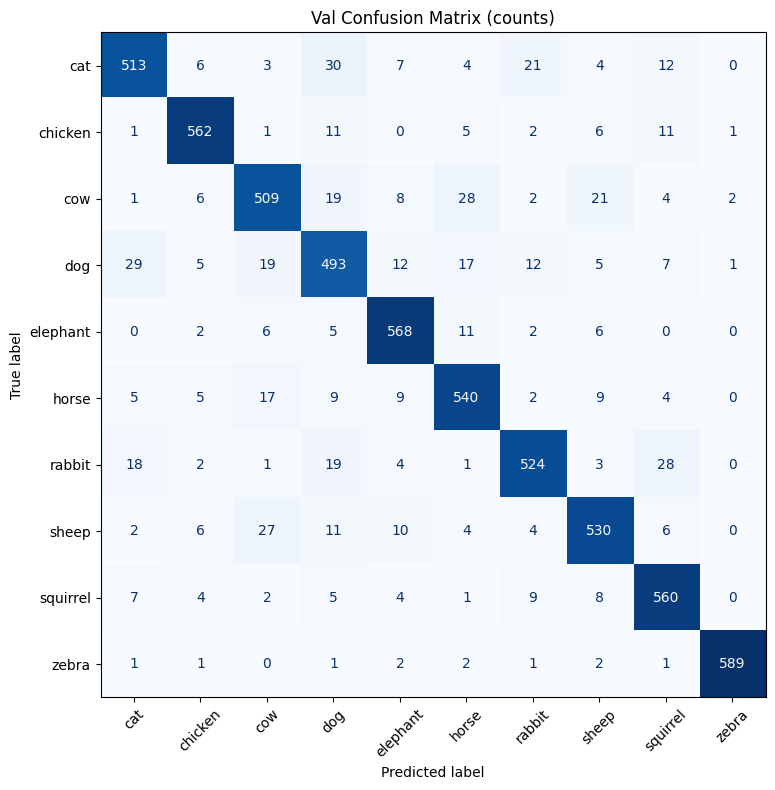

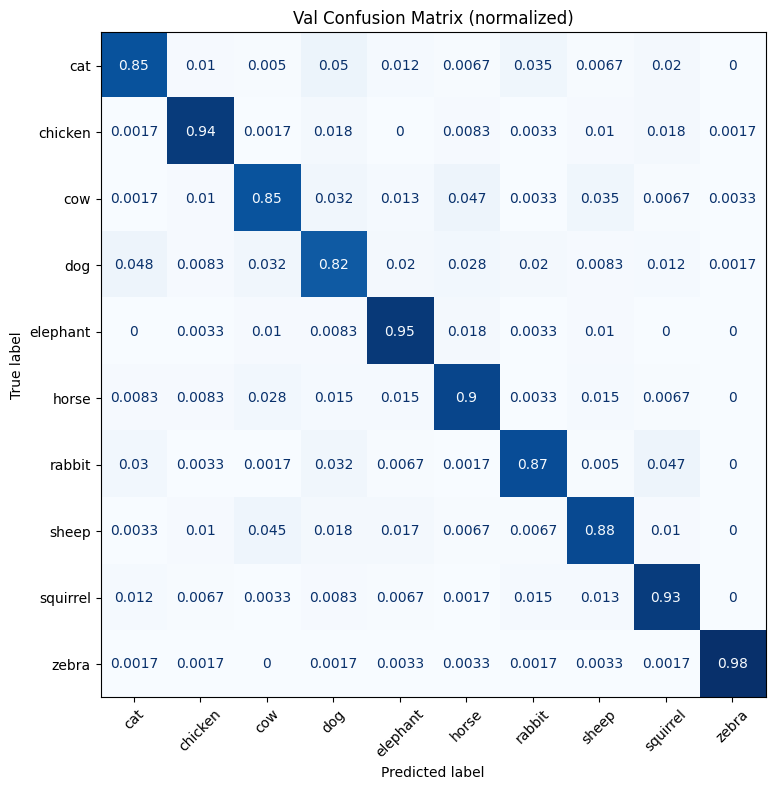

In [20]:
fig_counts = make_confusion_matrix_fig(
    y_true=y_true,
    y_pred=y_pred,
    class_names=class_names,
    normalize=None,
    title=f"{split_name.capitalize()} Confusion Matrix (counts)",
)

fig_norm = make_confusion_matrix_fig(
    y_true=y_true,
    y_pred=y_pred,
    class_names=class_names,
    normalize="true",
    title=f"{split_name.capitalize()} Confusion Matrix (normalized)",
)

with wandb.init(
    project=cfg.wandb.project,
    entity=cfg.wandb.entity,
    mode=cfg.wandb.mode,
    id=result["wandb_run_id"], # add to the same run!
    resume="must",              # for that, run is resumed
    job_type="log_confusion_matrix",
):
    try:
        log_confusion_matrix(
            y_true=y_true,
            y_pred=y_pred,
            class_names=class_names,
            key=f"{split_name}/confusion_matrix_chart",
            title=f"{split_name.capitalize()} Confusion Matrix",
            split_table=False,
        )
    except Exception as e:
        wandb.log({
            f"{split_name}/confusion_matrix_chart_error": str(e)
        })
        print("W&B custom confusion matrix failed:", e)

    wandb.log({
        f"{split_name}/confusion_matrix_counts": wandb.Image(fig_counts),
        f"{split_name}/confusion_matrix_normalized": wandb.Image(fig_norm),
    })

    wandb.finish()